## Customer Churn Prediction System Using Machine Learning, FastAPI, MLflow, Docker, AWS, and CI/CD

#### **Project Overview**

**Context**

**Telecommunication** companies act as the backbone of the global digital economy. They build, maintain, and operate the physical infrastructure that transmits voice, data, and video across vast distances. Their core responsibilities include providing internet access, facilitating mobile communications, and ensuring seamless connectivity for individuals, businesses, and governments.

The responsibilities and functions of a telecommunications company:
- Physical Deployment: They invest in and deploy the physical hardware required for connectivity, such as fiber-optic cables, cell towers, satellites, and undersea cables.
- Signal Transmission: They manage the transmission of signals using electromagnetic fields, wires, or light to ensure signals travel reliably from transmitters to receivers.
- Mobile Network Operations (MNOs): They provide mobile voice, text, and cellular data services to consumers through mobile devices.
- Internet Service Provision (ISP): They deliver high-speed broadband and dedicated internet connections to homes and organizations.
- Enterprise Solutions: They offer advanced business solutions like leased lines, Virtual Private Networks (VPNs), and data-centric solutions.
- Cloud & Hosting Services: As technology evolves, telecom companies provide cloud storage, hosting solutions, and computing infrastructure.
- Business Operations: They streamline global operations by enabling real-time communication, remote work, and virtual collaborations without regard for physical distance.

Telecommunication companies includes: MTN Nigeria, Airtel Nigeria, Globacom (Glo), 9mobile, Vodafone Group (UK), T-Mobile (US)


**Customer churn** is one of the most critical business challenges faced by subscription-based companies, especially in the telecommunications industry. Customer churn refers to the phenomenon where customers discontinue their relationship with a company by cancelling subscriptions, switching to competitors, or stopping the use of services.

Acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, organizations need predictive systems that can proactively identify customers who are likely to churn, allowing customer success teams, marketing departments, and business stakeholders to implement retention strategies before customers leave.

This project focuses on building an end-to-end Machine Learning Operations (MLOps) solution for customer churn prediction using:
- Machine Learning
- FastAPI
- MLflow
- Docker
- AWS Cloud Services
- GitHub Actions (CI/CD)
- Monitoring and Logging Frameworks

The solution covers the complete machine learning lifecycle from raw data ingestion to production deployment and monitoring.

### **Business Problem**

**Problem Statement**

Telecommunication companies lose substantial revenue when customers terminate their services. Traditional retention methods often rely on reactive approaches, where intervention occurs only after customers indicate dissatisfaction or leave.

The challenge is to develop an intelligent predictive system capable of:
- Identifying customers likely to churn.
- Estimating churn probability.
- Providing real-time predictions.
- Enabling proactive retention campaigns.
- Supporting business decision-making through data-driven insights.

### **Objectives**

The objectives of this project include:
- Reduce customer attrition rates.
- Increase customer lifetime value.
- Improve customer retention campaigns.
- Minimize revenue loss.
- Technical Objectives
- Build a robust churn prediction model.
- Automate the machine learning pipeline.
- Deploy the model as a REST API.
- Track experiments using MLflow.
- Containerize the application using Docker.
- Deploy the solution on AWS.
- Automate deployment using CI/CD.
- Monitor model performance in production.

### **Dataset Content**
The Telco Customer Churn dataset is an IBM sample dataset developed for educational and analytical purposes. It simulates customer information from a telecommunications company and contains demographic characteristics, subscribed services, account details, and billing information. The dataset is widely used for developing and evaluating machine learning models for customer churn prediction and retention analysis. Although the dataset resembles real-world telecom operations, it is synthetic and does not represent any specific telecommunications company.

IBM (International Business Machines Corporation) is a multinational technology company headquartered in Armonk, New York, USA. IBM is known for:
- Artificial Intelligence (Watson)
- Cloud Computing
- Data Science
- Enterprise Software
- Quantum Computing
- Machine Learning Solutions

The dataset represents a fictional telecommunications company. The customer records and service attributes are designed to resemble those of a telecom service provider offering:
- Phone services
- Internet services
- Online security
- Streaming TV and movies
- Technical support
- Various contract types and payment methods

The dataset mimics a real telecom business, it does not correspond to any specific telecommunications company, and customer identities are anonymized.

Each row represents a customer, each column contains customer’s attributes described on the column Metadata. The data set includes information about:
- Customers who left within the last month – the column is called Churn.
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies.
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges.
- Demographic info about customers – gender, age range, and if they have partners and dependents.

### **Data Dictionary**
- **customer_id**: Unique customer identifier.
- **gender**: Customer gender.(Male, Female).
- **senior_citizen**: Indicate whether a customer is an older adult who has reached a specific age threshold (usually 60 or 65). (1-yes, 0-No).
- **partner**: Indicate whether customer has a spouse or partner.(Yes, N0).
- **dependents**: Indicate whether customer has dependents.(yes, No).
- **tenure**: Indicate whether customer has stayed with the company.
- **contract_type**: Values includes month-month, one year, two year.
- **phone_service**: Indicate phone subscription availability.(Yes, No).
- **multiple_line**: Indicate whether multiple phone lines are subscribed. (Yes, No, No phone service).
- **internet_service**: Indicate the type of internet service provider.(DSL, Fiber optic, No).
- **online_security**: Indicate whether there is an online security subscription.(Yes, No, No internet service).
- **online_backup**: Indicate whether service backup avialable.(Yes, No, No internet service).
- **device_protection**: Indicate device protection service.(Yes, No, No internet service).
- **tech_support**: Indicate technical support subscription.(Yes, No, No internet service).
- **streaming_tv**: streaming tv subscription.(Yes, No, No internet service).
- **streaming_movies**: streaming movie subscription.(Yes, No, No internet service).
- **paperless_billing**: Indicate paperless billing status.(Yes, No).
- **payment_method**: Indicate customers payment method.(electronic check, mailed check, bank transfer, credit card).
- **monthly_charges**: Indicate monthly bill amount.
- **total_charges**: Indicate total accumulated charges.


### **Exploration Data Analysis**

In [309]:
# Importing Necessary Libraries for the EDA Process
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, RobustScaler, OneHotEncoder

In [310]:
# Loading the dataset and checking its shape
df = pd.read_csv('/Users/DELL/Desktop/AI_CODE_LAB_MLOPS/data/raw/Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [311]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

In [312]:
# Displaying a random sample of 3 rows from the dataset to understand its structure and contents
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3950,5655-JSMZM,Male,1,No,No,49,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.20,4718.25,Yes
2116,4349-GFQHK,Male,0,No,No,1,Yes,Yes,DSL,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,54.35,54.35,Yes
862,0947-MUGVO,Male,1,Yes,No,20,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,73.65,1463.5,Yes


In [313]:
# Getting a concise summary of the DataFrame, including the number of non-null entries and data types of each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [314]:
# Calculating the percentage of missing values in each column to identify any potential issues with data completeness
(df.isnull().sum() / len(df)) * 100

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [315]:
# Checking for duplicate rows in the dataset and counting them
df.duplicated().sum()  

np.int64(0)

In [316]:
# Column Standardization
Standardize = {
    'customerID': 'customer_id',
    'gender': 'gender',
    'SeniorCitizen': 'senior_citizen',
    'Partner': 'partner',
    'Dependents': 'dependents',
    'tenure': 'tenure',
    'PhoneService': 'phone_service',
    'MultipleLines': 'multiple_lines',
    'InternetService': 'internet_service',
    'OnlineSecurity': 'online_security',
    'OnlineBackup': 'online_backup',
    'DeviceProtection': 'device_protection',
    'TechSupport': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_movies',
    'Contract': 'contract',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges',
    'Churn': 'churn'
}
# Renaming the columns of the DataFrame using the Standardize dictionary to ensure consistency and readability.
df.rename(columns=Standardize, inplace=True)

# Removing leading and trailing whitespace from string columns to ensure data cleanliness.
for col in df.select_dtypes(include=['str']).columns:
    df[col] = df[col].str.strip()  

In [317]:
# Displaying the first few rows of the DataFrame to verify that the column names have been successfully standardized and to get an overview of the data.
df.head(2)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


### Data Validation

In [318]:
# Calculating the percentage of unique values in each column to understand the diversity of data and identify any potential issues with categorical variables or data encoding.
df.nunique() / len(df) * 100

customer_id          100.000000
gender                 0.028397
senior_citizen         0.028397
partner                0.028397
dependents             0.028397
tenure                 1.036490
phone_service          0.028397
multiple_lines         0.042595
internet_service       0.042595
online_security        0.042595
online_backup          0.042595
device_protection      0.042595
tech_support           0.042595
streaming_tv           0.042595
streaming_movies       0.042595
contract               0.042595
paperless_billing      0.028397
payment_method         0.056794
monthly_charges       22.504615
total_charges         92.730371
churn                  0.028397
dtype: float64

In [319]:
df.nunique()

customer_id          7043
gender                  2
senior_citizen          2
partner                 2
dependents              2
tenure                 73
phone_service           2
multiple_lines          3
internet_service        3
online_security         3
online_backup           3
device_protection       3
tech_support            3
streaming_tv            3
streaming_movies        3
contract                3
paperless_billing       2
payment_method          4
monthly_charges      1585
total_charges        6531
churn                   2
dtype: int64

Unique IDs: Every customer must have a unique ID.

In [320]:
# Calculating the number of unique customers in the dataset by counting the unique values in the 'customer_id' column and comparing it to the total number of rows to check for any duplicate customer entries
print(df["customer_id"].nunique())
print(len(df))

7043
7043


Senior citizen: Allowed values (0, 1)

In [321]:
# Checking the unique values in the 'senior_citizen' column to understand the distribution of senior citizens in the dataset and to identify any potential issues with data encoding or categorization.
print(df["senior_citizen"].unique())

[0 1]


Tenure: customer lifetime in months (0 and 72 month).

A 72-month maximum limit (6 years) is standard because customer data is usually capped for accurate, long-term financial modeling.

In [322]:
# Calculating the descriptive statistics for the 'tenure' column to understand the distribution of customer tenure, including measures of central tendency and variability, which can provide insights into customer retention and loyalty.
print(df["tenure"].describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [323]:
# Calculating the frequency of each unique value in the 'tenure' column to understand the distribution of customer tenure and to identify any potential patterns or trends in customer retention.
df["tenure"].value_counts().sort_index().head()

tenure
0     11
1    613
2    238
3    200
4    176
Name: count, dtype: int64

Monthly Charges: Must be numeric and also greater than 0

In [324]:
# Calculating the descriptive statistics for the 'monthly_charges' column to understand its central tendency, dispersion, and overall distribution, which can help identify any potential outliers or skewness in the data.
print(df["monthly_charges"].describe())

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64


Total Charges: Must be numeric, greater than 0 and free of blank spaces

In [325]:
# Calculating the number of blank values in the 'total_charges' column to identify any potential issues with data completeness or formatting that may need to be addressed before further analysis.
blank_values = (df["total_charges"].astype(str).str.strip() == "")
print(f"Number of blank values in total charges: {blank_values.sum()}")

Number of blank values in total charges: 11


In [326]:
# Converting the 'total_charges' column to numeric data type, coercing any non-numeric values to NaN, to ensure that the data is in the correct format for analysis and to handle any potential issues with data cleanliness or formatting.
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

In [327]:
# Calculating the number of null values in the 'total_charges' column after coercion to identify any potential issues with data completeness or formatting that may need to be addressed before further analysis.
print(df["total_charges"].isnull().sum())

11


In [328]:
# Calculating the number of negative values in the 'total_charges' column to identify any potential issues with data integrity or formatting that may need to be addressed before further analysis.
negative_total = df[df["total_charges"] < 0]["total_charges"].count()
print(negative_total)

0


In [329]:
# Extracting the rows with null values in the 'total_charges' column to further investigate the nature of these missing values and to determine if there are any patterns or commonalities among these rows that may help inform data cleaning or imputation strategies.
missing_rows = df[df["total_charges"].isnull()]
missing_rows

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [330]:
# Imputing the missing values in the 'total_charges' column with 0 for rows where 'tenure' is 0, as it is reasonable to assume that customers with no tenure would not have any total charges, thereby addressing the issue of missing values in a logical manner.
df.loc[(df["total_charges"].isnull()) & (df["tenure"] == 0), "total_charges"] = 0

# Calculating the number of null values in the 'total_charges' column after imputation to verify that the missing values have been successfully addressed and to ensure that there are no remaining issues with data completeness in this column.
print(df["total_charges"].isnull().sum())

# This approach preserves the business meaning of the data and is generally preferable in a production-grade customer churn prediction pipeline.

0


In [331]:
# Converting senior_citizen column to categorical data type to ensure that it is treated as a categorical variable in analysis and modeling, which can help improve the accuracy and interpretability of results.
df["senior_citizen"] = df["senior_citizen"].astype("str")

In [332]:
# Showing the categorical columns in the dataset by identifying columns that have a data type of string and contain fewer than 10 unique values, which can help in understanding the structure of the data and in selecting appropriate encoding techniques for machine learning models.
categorical_cols = []
for col in df.columns:
    if (df[col].dtype == "str") and (df[col].nunique() < 10):
        categorical_cols.append(col)
print(categorical_cols)
print(len(categorical_cols))

['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'churn']
17


In [333]:
# Showing the numeric columns in the dataset by selecting columns with data types of int64 or float64, which can help in understanding the structure of the data and in selecting appropriate analysis techniques for numerical variables.
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_cols)
print(len(numeric_cols))

['tenure', 'monthly_charges', 'total_charges']
3


In [334]:
# Displaying the unique values in each of the categorical columns to understand the distribution of categories and to identify any potential issues with data encoding or categorization that may need to be addressed before further analysis.
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
    print("="*50)

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
senior_citizen: <StringArray>
['0', '1']
Length: 2, dtype: str
partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
phone_service: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
multiple_lines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
internet_service: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
online_security: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
online_backup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
device_protection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
tech_support: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
streaming_tv: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
streaming_movies: <StringArray>
['No', 'Yes', 'No internet service']
Length

### Statistical Summary

In [335]:
# Calculating the descriptive statistics for all columns in the dataset, including both numeric and categorical variables, to gain a comprehensive understanding of the data distribution, central tendency, and variability, which can help inform further analysis and modeling decisions.
df.describe(include = 'all')

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
count,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,0,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,5901,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


### Univariate Analysis

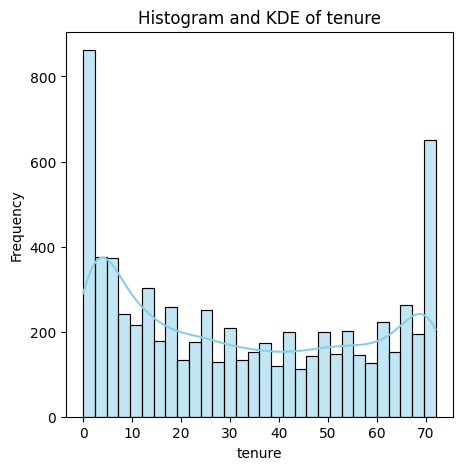

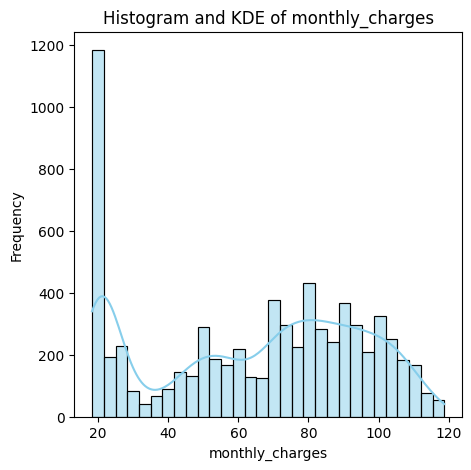

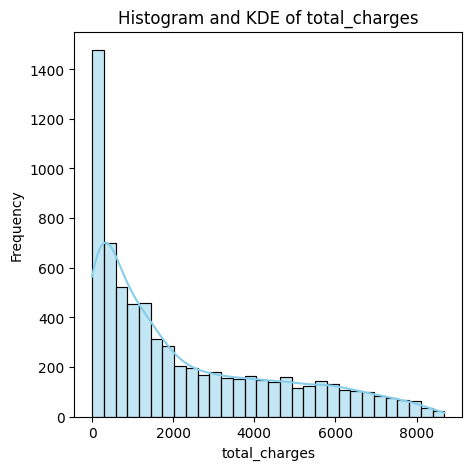

In [336]:
# Visualizing the distribution of numeric columns using histograms and kernel density estimates (KDE) to understand the shape of the data, identify any potential outliers or skewness, and to inform decisions about data transformation or modeling techniques.
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(data=df, x=col, kde=True, bins = 30, color = "skyblue")
  plt.title(f"Histogram and KDE of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

**OBSERVATION**

Tenure
- Many customers are relatively new.
- Another large group consists of long-term customers.
- Tenure distribution is bimodal.

Monthly Charges
- Monthly charges exhibit a multi-modal distribution.
- Customers cluster around low and high monthly charge ranges.

Total Charges
- Distribution is positively skewed.
- Majority of customers have relatively low total charges.
- Few customers have accumulated very high charges.

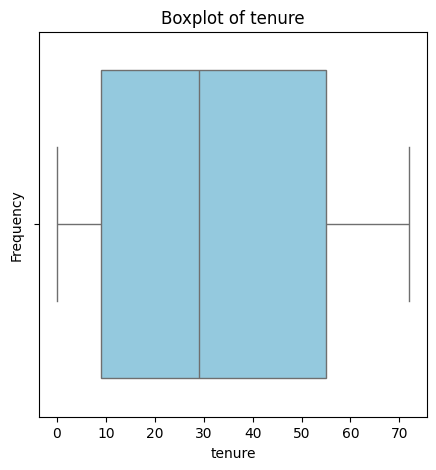

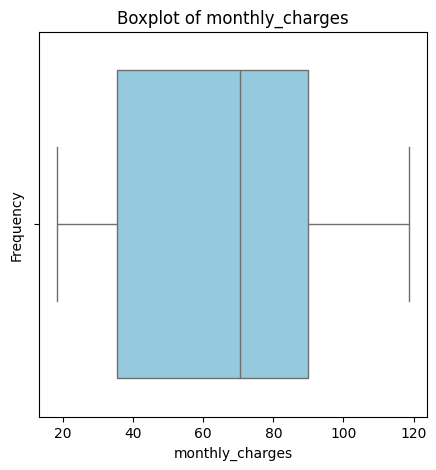

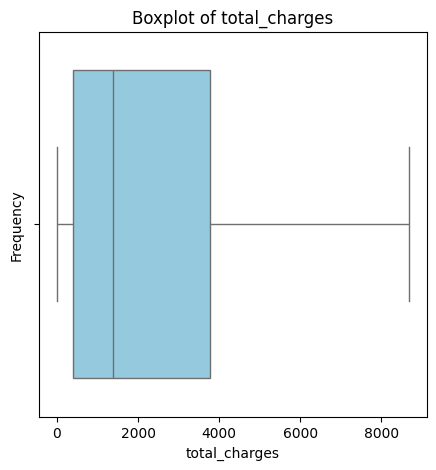

In [337]:
# Visualizing the distribution of numeric columns using boxplots to identify any potential outliers, understand the spread of the data, and to inform decisions about data transformation or modeling techniques.
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(data=df, x=col, color = "skyblue")
  plt.title(f"Boxplot of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

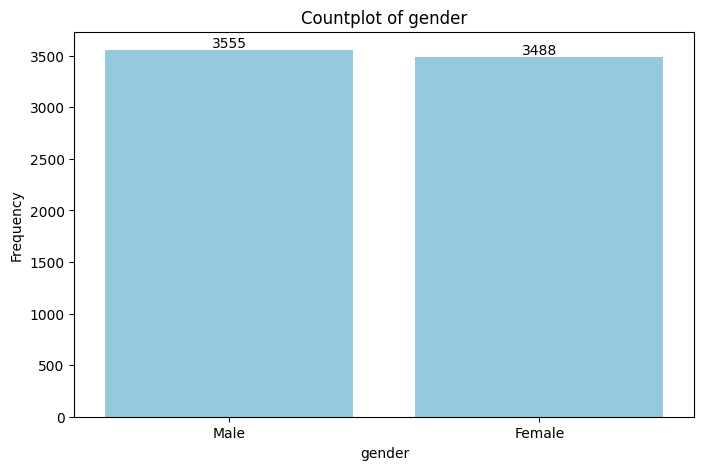

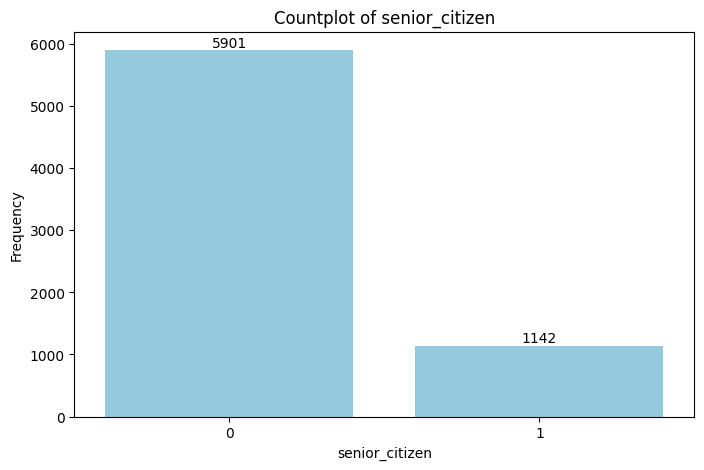

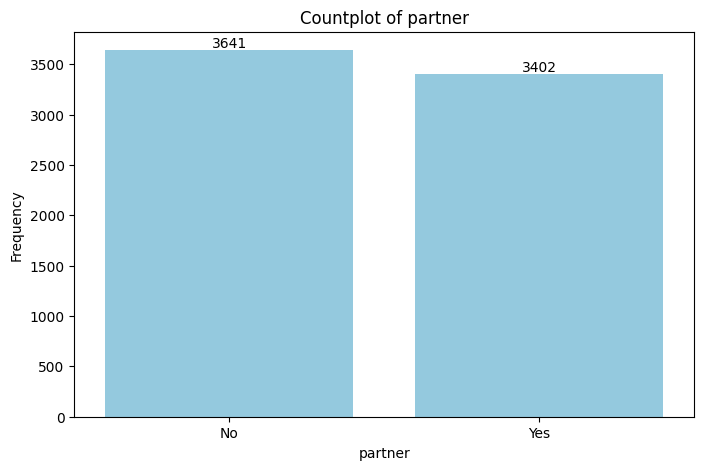

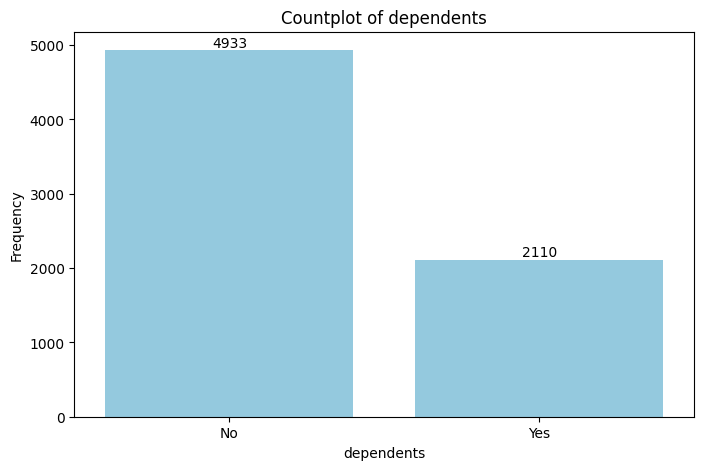

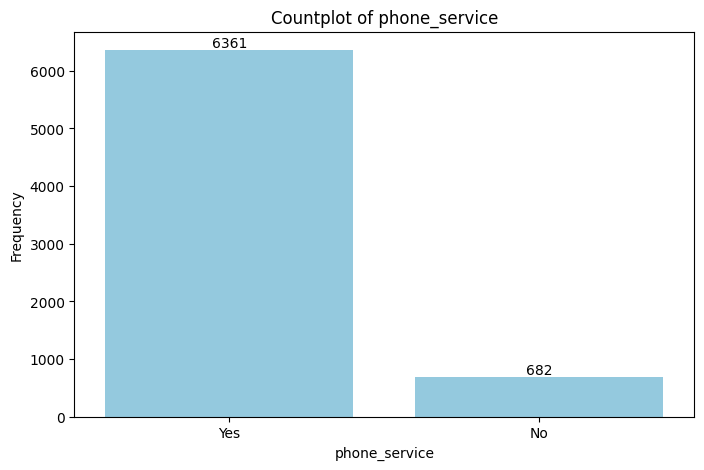

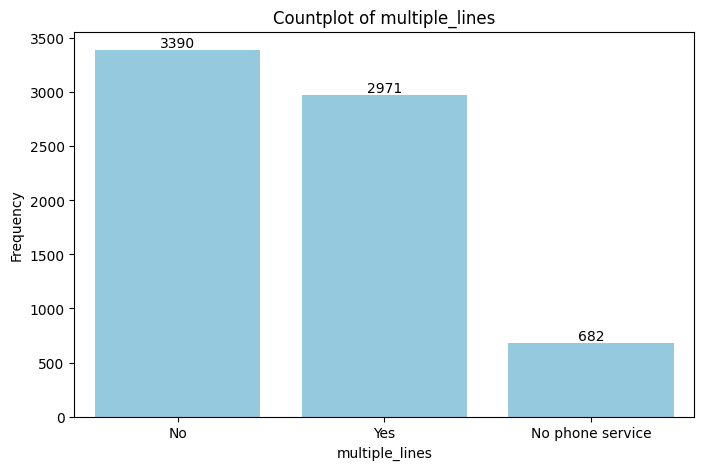

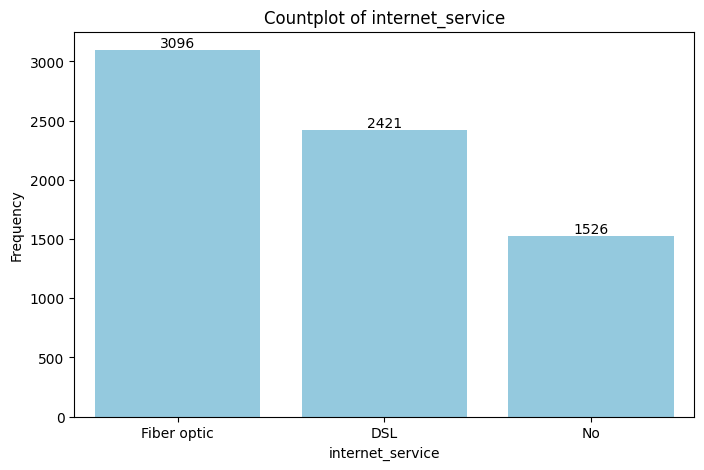

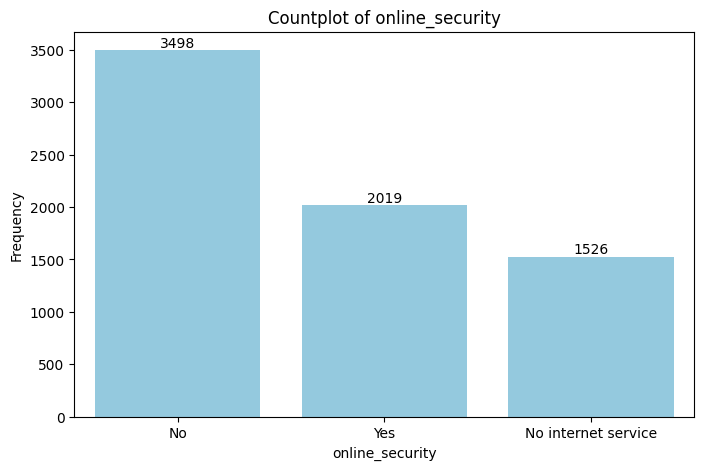

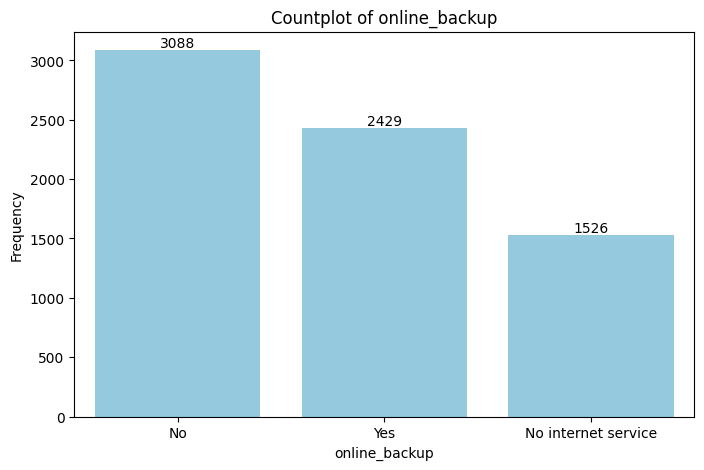

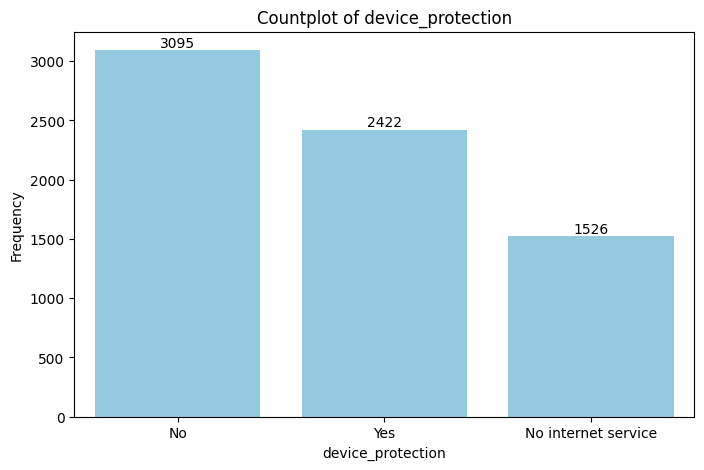

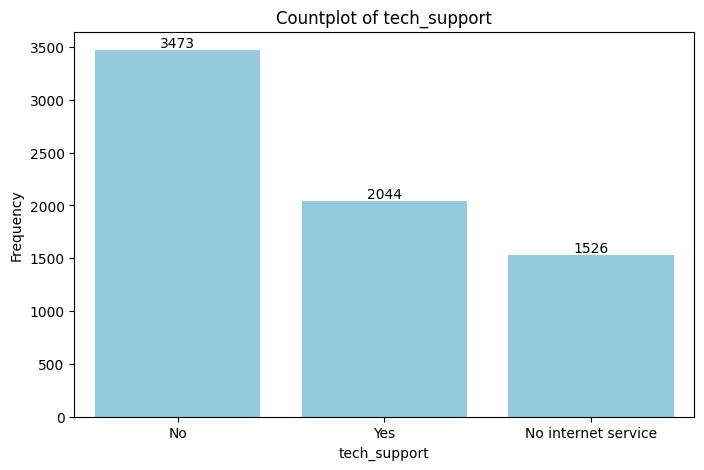

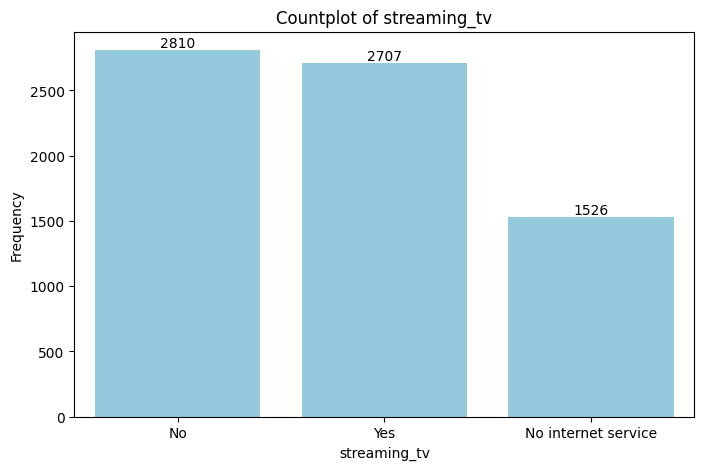

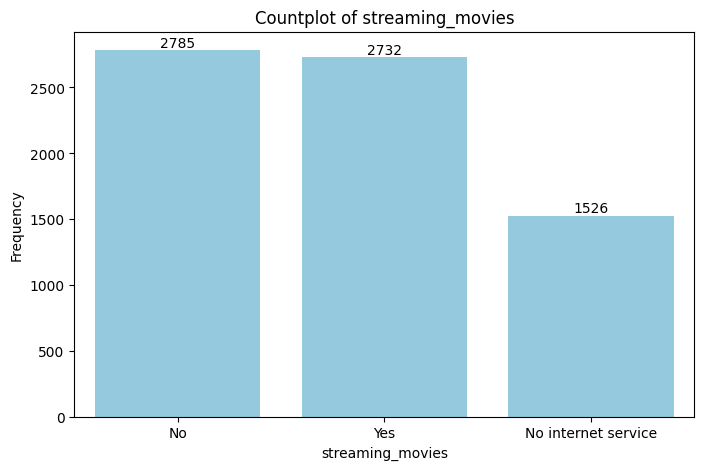

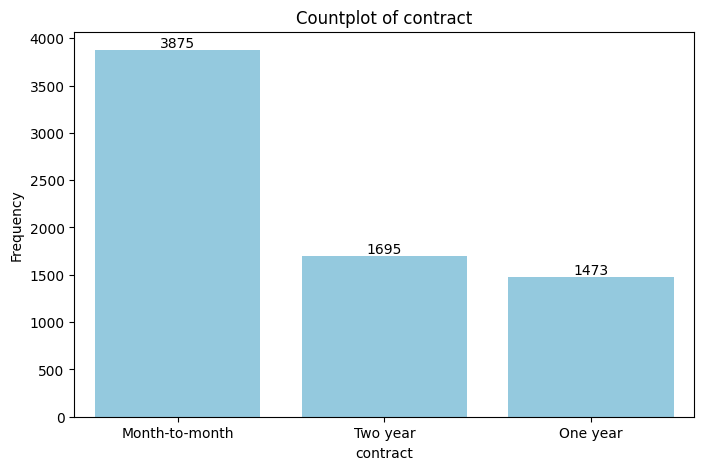

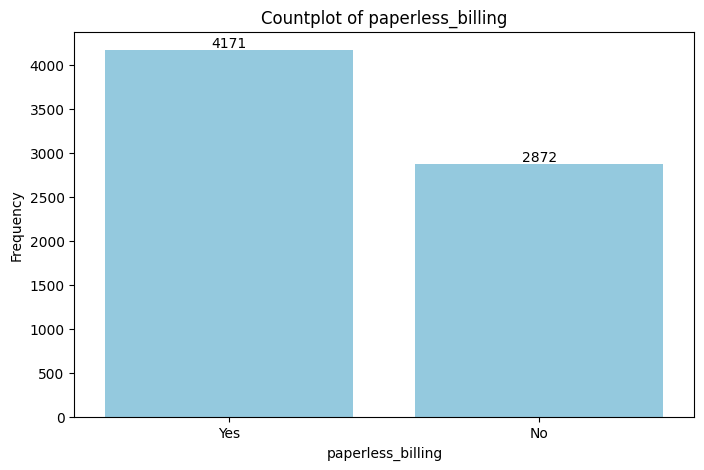

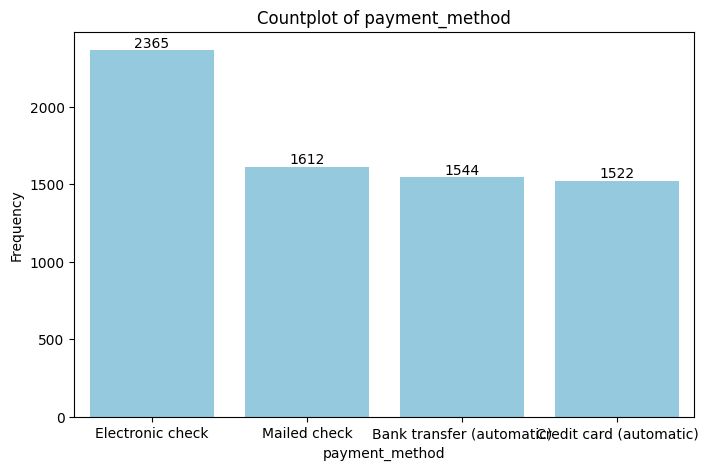

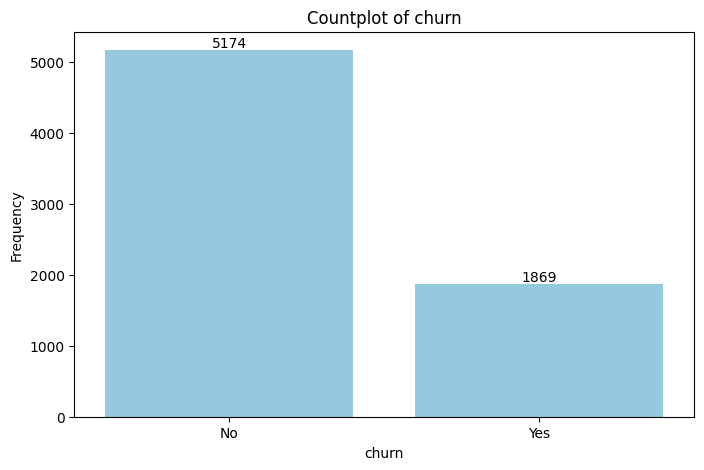

In [338]:
# Visualizing the distribution of categorical columns using countplots to understand the frequency of each category, identify any potential imbalances in the data, and to inform decisions about encoding techniques for machine learning models.
for col in categorical_cols:
  plt.figure(figsize=(8,5))
  ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, color = "skyblue")
  for container in ax.containers:
    ax.bar_label(container)
  plt.title(f"Countplot of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

**OBSERVATION**

Gender
- Male and female customers are almost equally distributed.

Senior Citizen
- Majority of the customers are not senior citizen, while a much smaller group are senior citizen.

Partner
- Customers with partners and without are almost equally distributed with customers with partners having a slighly smaller portion of the data.

Dependent
- There is a significant disparity between the two categories. A much larger portion of the customer does not have dependents compared to those who do.

Phone Service
- Majority of customers have phone service, distribution(Yes:6321, No:682). Suggesting that phone service may have low predictive variance.

Multiple Line
- No: 3390 customers have a single phone line.
- Yes: 2971 customers have multiple lines.
- No phone service: 682 customers do not have phone service at all.

Internet Service
- Fiber optic is the most popular service (3096 customers), followed by DSL (241 customers), and the least common is the No internet (1526 customers).

Online Security
- The majority of customers (3498) do not have online security, while 2019 customers have opted for it, and 1526 have no internet service.

Online Backup
- 3088 customers does not utilize online backup servive, 2429 customers have online backup, a samller segment of 1526 customers has no internet service.

Device Protection
- No: 3095 customers, these customers do not have an additional protection plan.
- Yes: 2422 customers, these customers have opted for the protection service.
- No internet servive: 1526 customers, these are customrs who likely only have phone services, making them
in eligible for device protection.

Tech Support
- No: This category has the largest customers count of 3473, these are customers with no technical support.
- Yes: 2044 customers, these are customers that do not subscribe to technical support service.
- No internet servive: 1526 customers, these are customrs without internet service, for whom tech support 
is naturally not applicable.

Streaming TV
- There is a ralatively balanced distribution between customers who use streaming services(2707) and those who do not(2810). The no internet category of customers is distinct because the customers lack the infrastructure to use value added services, making them a unique segment for retention strategies.

Streaming Movies
- There is a ralatively balanced distribution between customers who have internet service but do not use for movie(2785) and customers who actively use their internet for streaming movies. The no internet category has the least customers, these are customers without an internet data plan (likely phone-only).

Contract Type
- Month-to-month contracts dominate the dataset with count of 3875. In churn prediction, this group typically represent the highest risk. Since this customers aren't locked into long-term agreements, they can leave at any time with minimal friction.

Paperless Billing
- Understanding how billing preferences might actuall influence customer attrition.
- Yes (Paperless): Approximately 4171 customers are enrolled in paperless billing.
- No (Traditional): Approximately 2872 customers are enrolled in trasitional billing.

Payment Method
- Electronic check category is the most frequent payment method with 2365 customers using it. Mail check category having customers count of 1612. Bank transfer(automatic) and Credit card(automatic) categories show lower frequencies of 1544 and 1522 respectively. 

Churn
- The churn distribution reveals an imbalanced between the categories(Yes and No). For No(Non-churners) we have 5174 customers belonging to this category, and for Yes(Churners) we have 1869 customers belonging to this category as well. 

### Bivariate Analysis

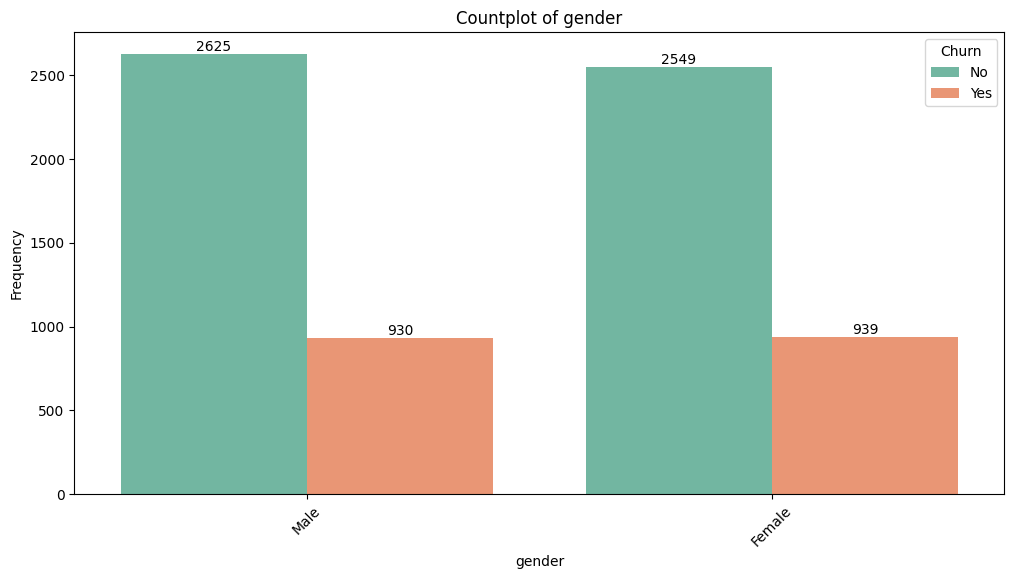

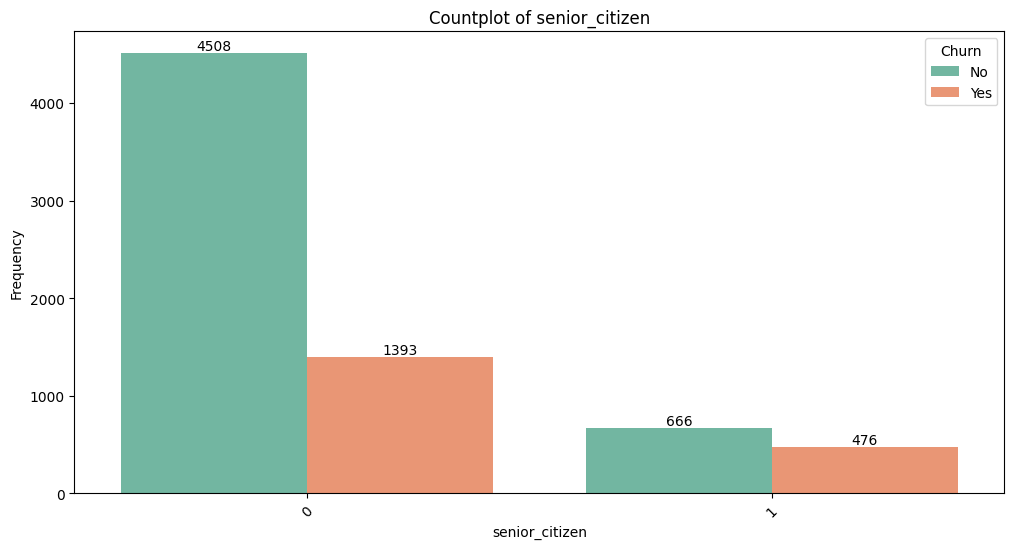

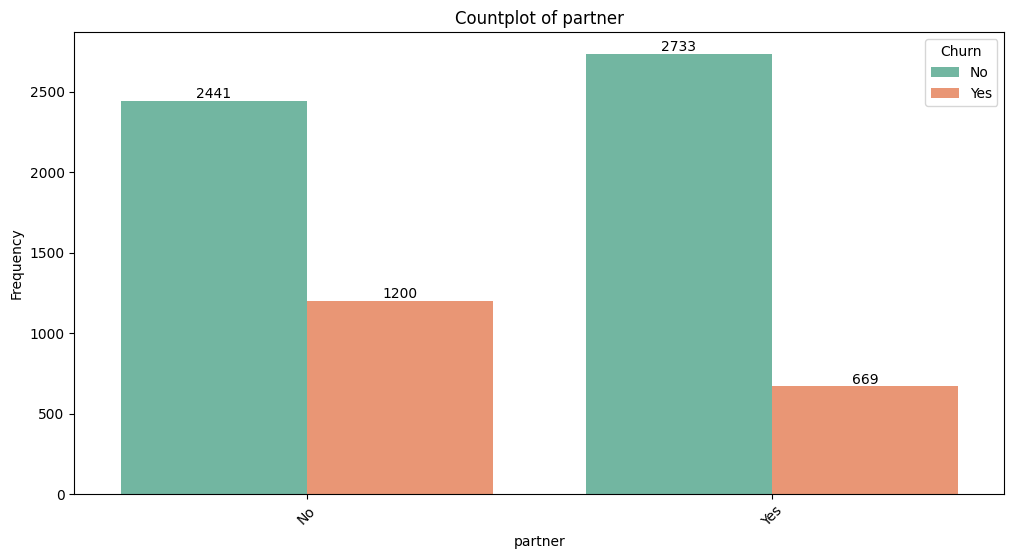

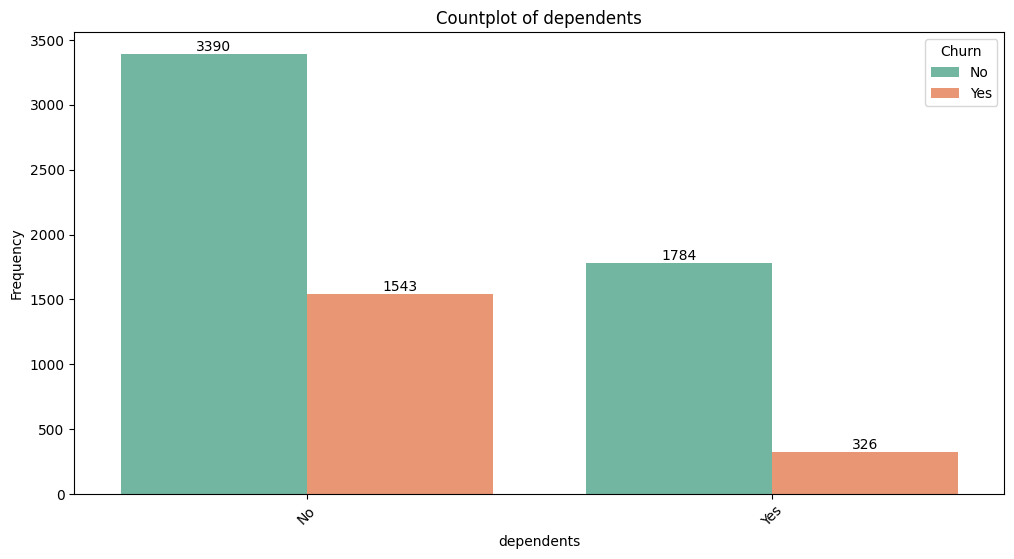

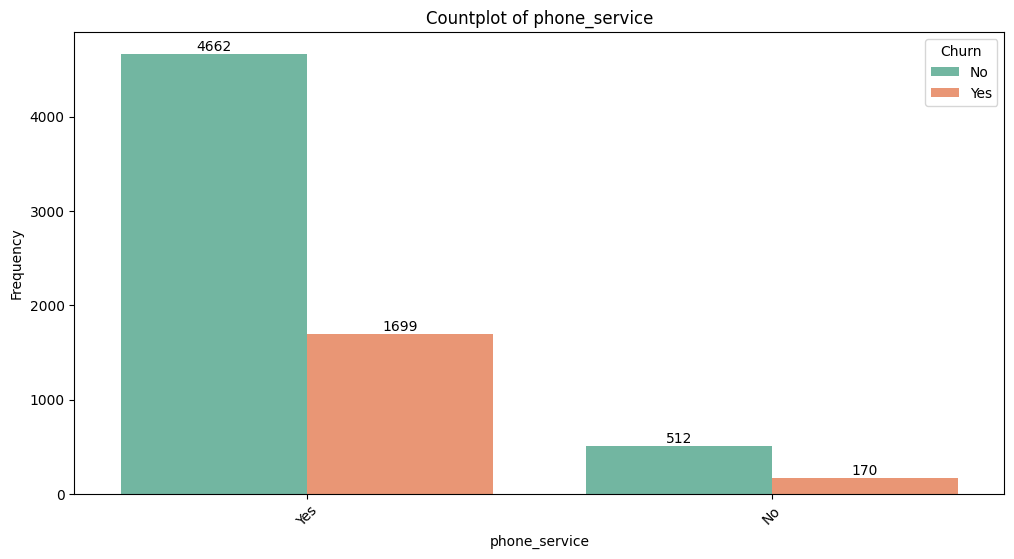

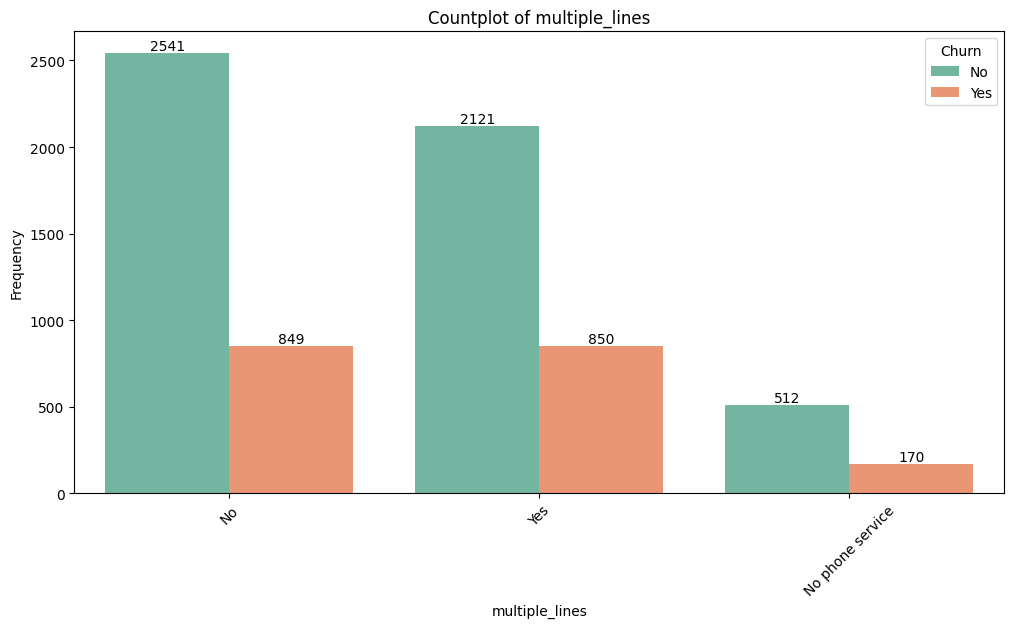

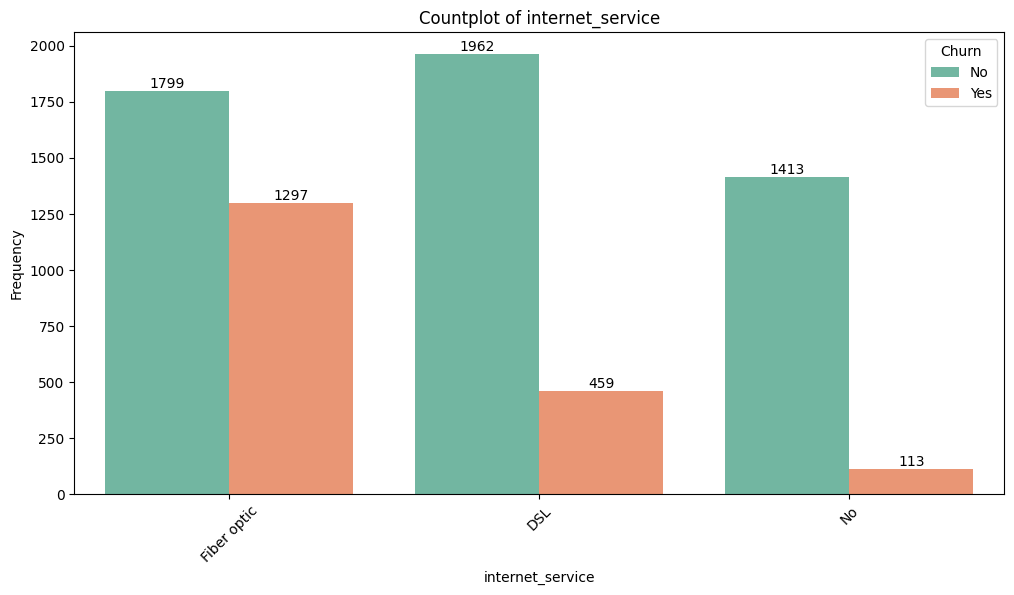

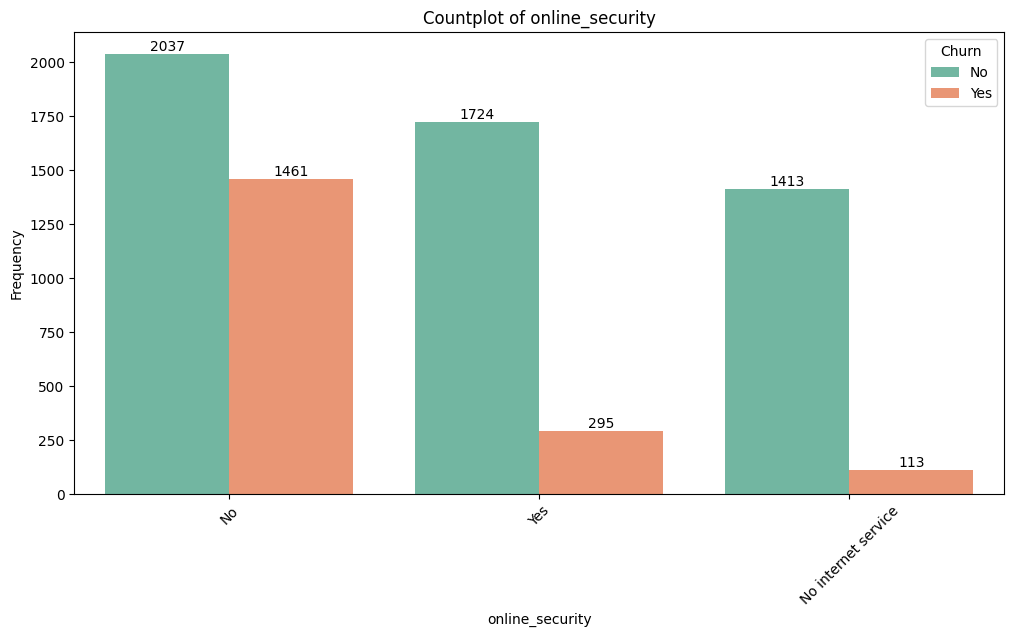

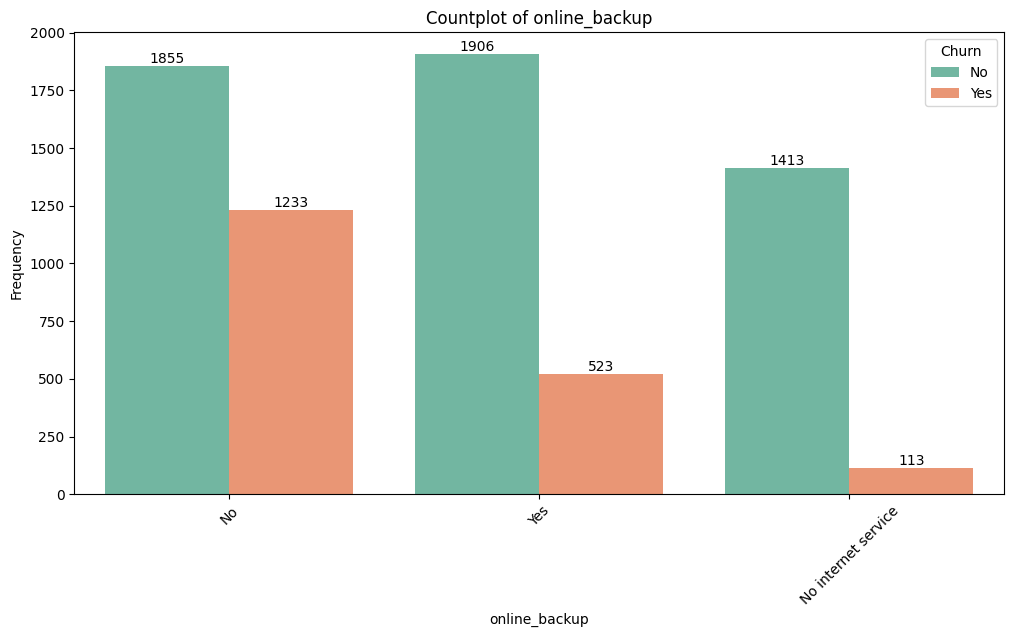

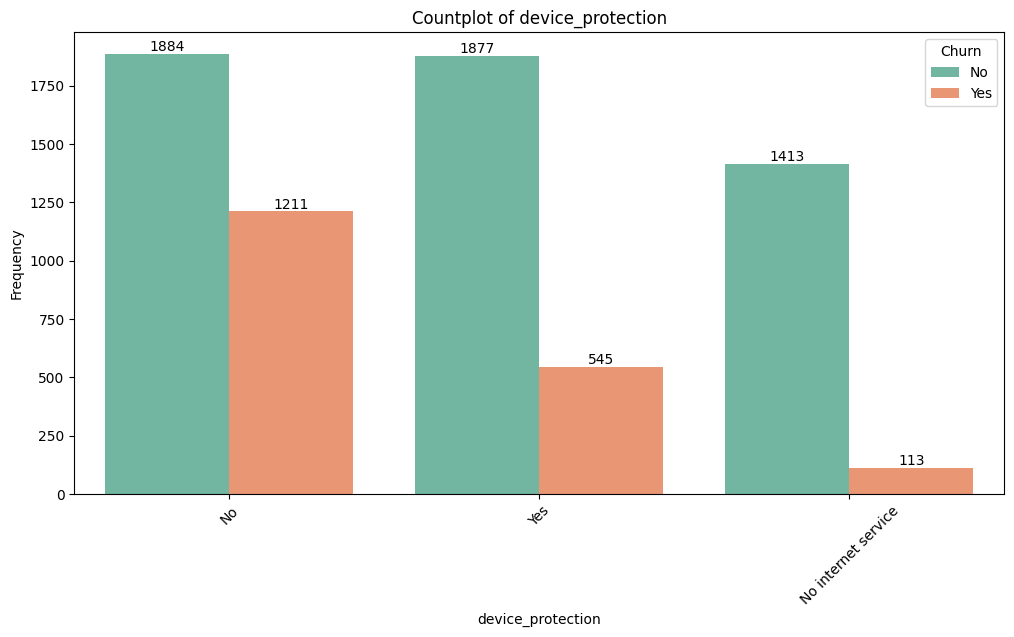

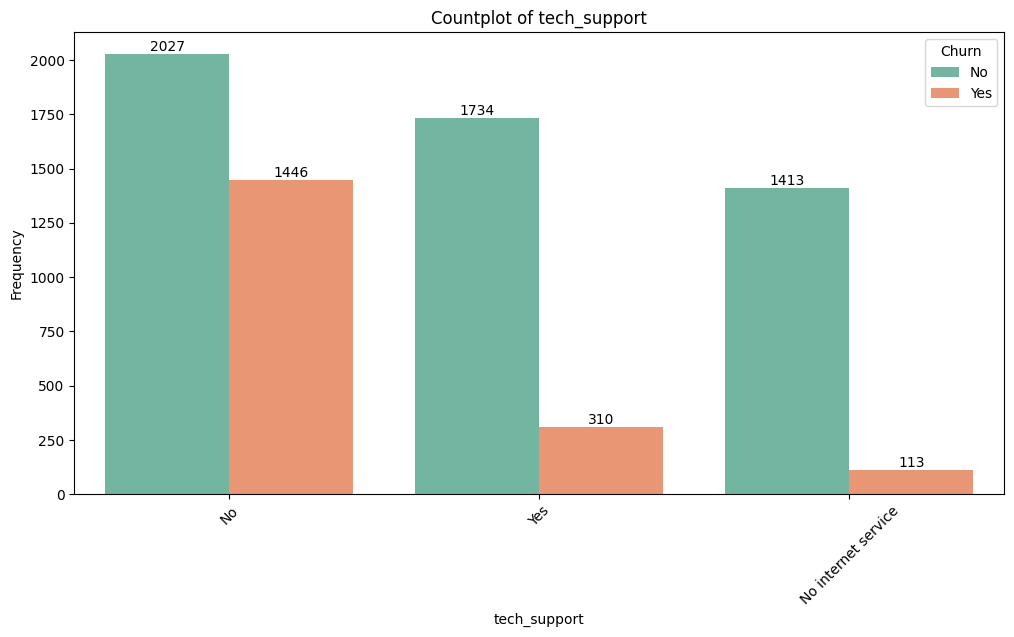

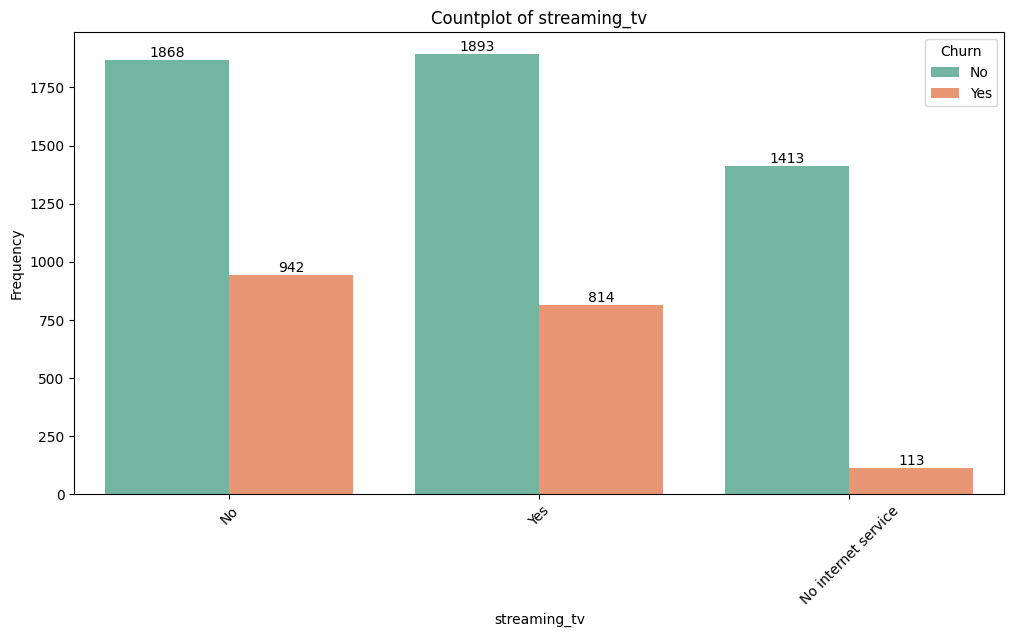

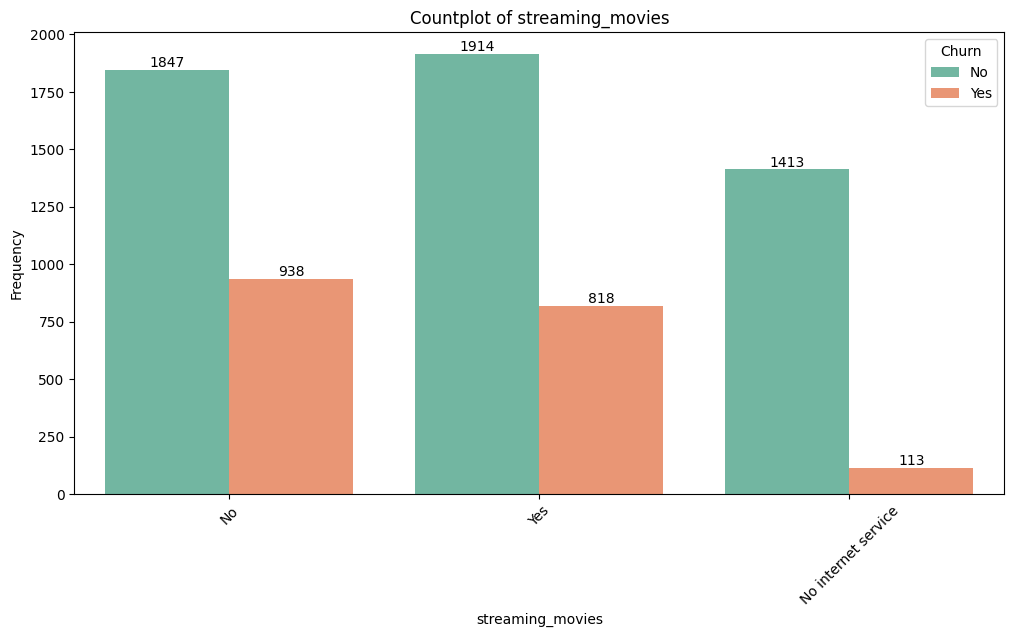

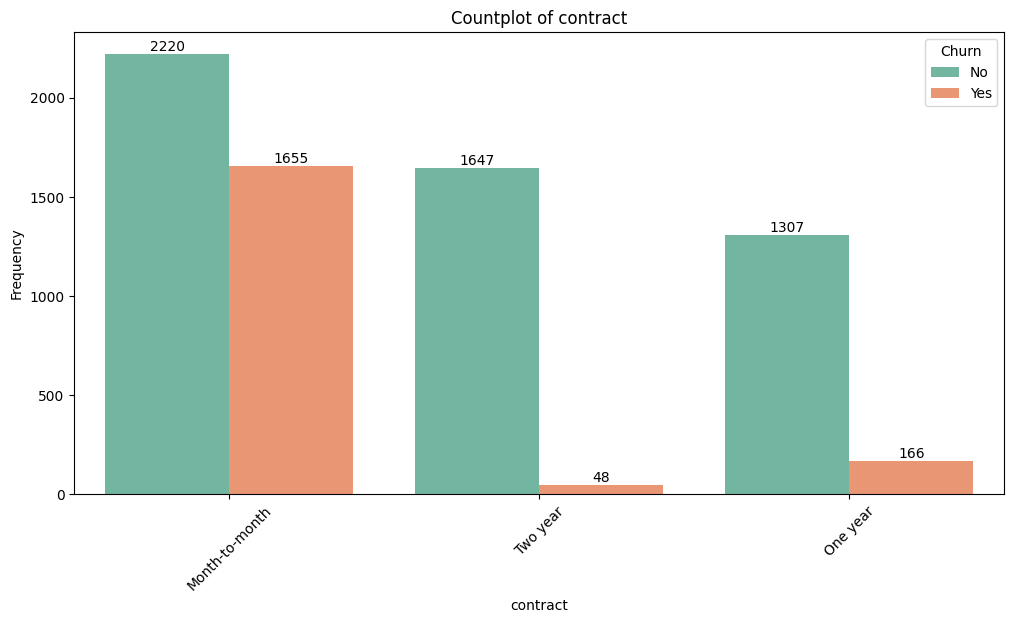

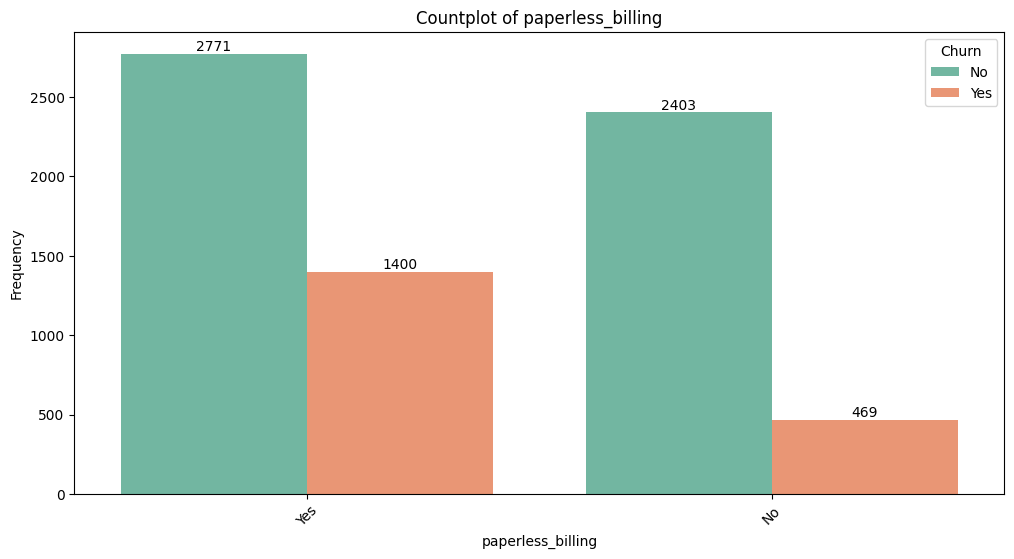

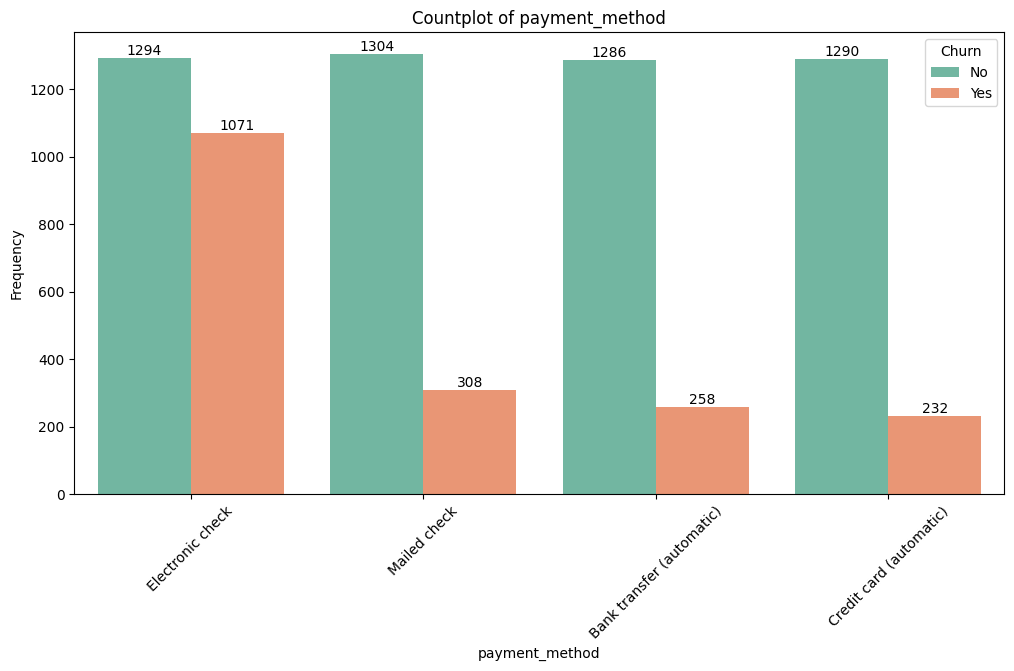

In [ ]:
# Visualizing the distribution of categorical columns using countplots with hue set to 'churn' to understand the relationship between each categorical variable and customer churn, identify any potential patterns or trends in the data, and to inform decisions about feature selection and modeling techniques for customer churn prediction.
for col in categorical_cols:
  plt.figure(figsize=(12,6))
  ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set2', hue='churn')
  for container in ax.containers:
    ax.bar_label(container)
  plt.title(f"Countplot of {col}")
  plt.xlabel(col)
  plt.xticks(rotation=45)
  plt.ylabel("Frequency")
  plt.legend(title='Churn', loc='upper right')
  plt.show()


**OBSERVATION**

Gender
- The absolute number of customers who churned(Yes) is nearly identical between Male (930) and Female (939) groups. Similarly, the number of customers who stayed (No) is very high and comparable for both genders (2625 for male and 2549 for female). Gender appears to be a weak predictor for churn in this dataset. Since the churn rate is almost unniform across both categories, this feature may not provide high information gain for ML model.

Senior Citizen
- While senior citizens make up a samller portion of the total customers, they exhibit a significantly higher churn rate (approx. 41.7%) compared to non-senior citizens (approx. 23.6%). Although the absolute number of churners is higher among non-seniors (1393 vs 476), the proportional risk is much higher for seniors. The status of being a senior citizen appears to be a strong predictor for churn, as the likelihood of leaving nearly doubles for this demographic in this data.

Partner
- Customers with a partners(Yes) show a significantly lower churn count (669) compared to those without a partner (1200). The group with partners has a much higher retention count (2733) compared to the group without(2441), despite the total number of customers with partners being higher.  Being single appears to be a strong risk factor for churn. Customers with partners may have more stable lifestlyes or multi-user accounts that increase their 'stickiness' to the service.

Dependent
- Customers without dependents (No) show a significantly higher volume of churn (1543) compared to those with dependents(326). While the total number of customers without dependents is higher, the ratio of churn to non-churn is much larger in the No dependents group. Having no dependents appears to be a strong indicator of churn risk. Conversely, customers with dependents seem more stable and less likely to leave the service.

Phone Service
- Customers with phone services show a significantly higher absolute number of churned cases(1699) compared to those without service(170). The churn rates are relatively similar, suggesting phone service alone may not be a strong individual predictor of churn risk, though the volume of yes users makes them the primary focus for retention. 

Multiple Line
- The highest absolute number of churned customers(Yes-850) occurs among those with multiple lines, closely followed by those with a single line(No-849). Customers with no phone service show the lowest frequency of churn(170), though they also represent the smallest segment of the data. Customers with a single line(No) represent the largest group of non-churners(2541), indicating higher stability in this segment compared to those with multiple lines.

Internet Service
- Fiber Optic high churn risk: Customers with fiber optic internet have a significantly higher churn rate compared to other groups. Nearly 42% (1297 out of 3096) of fiber optic users churned.
- DSL stability: DSL users show much higher loyalty, with a churn rate of approximately 19%.
- No Internet Service is safest: Customers without internet service have the lowest churn volume and rate (about 7%), suggesting they are the most stable segment.

Online Security
- No Online Security: Customers without online security have the highest churn rate. While they represent the largest group (2,037), a substantial number (1,461) have left, suggesting this lack of service is a major churn driver.
- With Online Security: Customers who do have online security are much more loyal. Only 295 out of 1,724 have churned, showing a drastically lower churn ratio compared to those without the service.
- No Internet Service: This group has the lowest overall churn (113), likely because they have fewer services to cancel or lower monthly costs.

Offering or incentivizing Online Security appears to be a highly effective strategy for customer retention. Users without this service are at the highest risk of leaving.

Online Backup
- Churn Correlation: Customers without online backup exhibit a significantly higher churn rate compared to those who have the service.
- Retention Factor: Having online backup or having "No internet service" correlates with much lower churn numbers, suggesting these attributes are strong indicators of customer loyalty.

Device Protection
- Highest Churn Risk: Customers with no device protection exhibit the highest volume and proportion of churn (approx. 39%).
- Retention Correlation: Having device protection significantly correlates with lower churn; the churn count drops by more than half compared to those without it (dropping to approx. 22%).
- Low Friction Segment: The "No internet service" group has the highest retention rate, with a very small fraction of customers leaving the service (approx. 7%).

In short, device protection is a strong negative predictor of churn—customers with this feature customers are much more likely to stay.

Tech Support
- Higher Retention with Tech Support: Customers with Tech Support ("Yes") have a significantly lower churn rate compared to those without it. This suggests that offering technical assistance is a strong retention factor.
- High Risk in "No Tech Support" Group: The "No" tech support category shows the highest volume of churned customers (1,446). This group represents a primary risk segment for the prediction model.
- Lowest Churn in "No Internet Service": While this group has the smallest overall count, their churn volume (113) is minimal, likely because they lack the specific services that typically drive technical friction.

Streaming TV
- Churn Volume: The highest volume of churn occurs among customers who do not use the Streaming TV service (942) followed closely by those who do use it (814).
- Churn Proportion: While the absolute number of churners is highest in the "No" category, the gap between "No Churn" and "Churn" is narrower for both Streaming TV users and non-users compared to those with no internet service.
- No Internet Service: This group has the lowest churn rate (113), suggesting these customers are highly stable or have fewer competitive alternatives

Streaming Movies
- Customers who stream movies ("Yes") show a higher volume of retention (1914) compared to those who don't (1847). However, the absolute number of churned customers is also higher in the streaming group (818 vs. 938).
- No Streaming: Churn rate is approximately 33.7%. Streaming Movies: Churn rate is approximately 30.0%.Streaming customers appear slightly more likely to stay, but the difference is marginal.
- The "No Internet Service": Customers without internet service have the lowest churn rate by far. With only 113 churns against 1413 retentions, their churn rate is roughly 7.4%.

Inference: This suggests that the core churn issue is heavily tied to internet-based features or pricing, rather than the streaming service itself. Customers with simpler service packages are significantly more stable. Streaming behavior is a weak predictor of churn on its own, as the ratios are similar. However, the absence of internet service is a very strong indicator of high customer retention.

Contract Type
- Month-to-Month Risk: This category has the highest volume of churn (1,655), showing a significantly higher churn rate compared to other contract types.
- Long-Term Loyalty: Two-year and one-year contracts exhibit very high retention, with the two-year group showing the lowest churn (only 48).

Contract type appears to be a strong indicator of churn; month-to-month status is a major risk factor, while longer commitments correlate with stability.

Paperless Billing
- Paperless Billing (Yes): There is a significantly higher frequency of churn here. Out of approximately 4,171 customers, 1,400 have churned, resulting in a churn rate of roughly 33.5%.
- Paperless Billing (No): Customers without paperless billing show much higher loyalty. Only 469 out of 2,872 customers churned, a much lower rate of approximately 16.3%.

The stark difference in churn rates suggests that paperless_billing is a strong indicator of customer behavior. A machine learning model would likely assign high feature importance to this variable.

Payment Method
- Payment Method Preferences: Customers are fairly evenly distributed across the four payment methods, with Electronic check and Mailed check having slightly higher total counts.
- The "Electronic Check" Red Flag: This category shows a disproportionately high churn rate. While the "No" churn count (1294) is similar to other categories, the "Yes" churn count (1071) is massive. This suggests that customers using electronic checks are significantly more likely to leave.
- Stability in Automation: Conversely, Bank transfer (automatic) and Credit card (automatic) show very low churn relative to their total volume. Automatic payments often act as a "lock-in" mechanism that correlates with higher customer retention.
- Mailed Checks: This method has a moderate churn count (308), which is higher than the automatic methods but much lower than electronic checks 

Churn
- Class Imbalance: There is a notable imbalance between the two classes.
    - No (Stayed): 5,174 customers
    - Yes (Churned): 1,869 customers
- Churn Rate: Roughly 26.5% of the data represents customers who have churned.

In a machine learning context, this distribution tells us several things about how to approach the model:
- Avoid Accuracy Alone: Since nearly 74% of the data is "No," a model could achieve 74% accuracy just by predicting that nobody will churn. This would be a failure, as the goal is to identify the "Yes" cases.
- Evaluation Metrics: we should prioritize metrics like Recall (to capture as many actual churners as possible) and Precision (to ensure identified churners are likely to actually leave). 
- The F1-score or AUC-ROC will be more informative than raw accuracy.
- Resampling Techniques: To improve performance, you might need to use techniques like SMOTE (oversampling the minority "Yes" class) or undersampling the majority "No" class to help the model learn the patterns of churners more effectively. 

### **Feature Engineering**

##### - Checking for Skeweness

In [ ]:
# Defining a function to check the skewness of numeric columns in the dataset and categorize them into perfect skewness, approximate symmetry, moderate skewness, and high skewness based on their skewness values, which can help inform decisions about data transformation or modeling techniques for machine learning models.
def check_skew(data_skew):
  perfect_skew = []
  approximate_skew = []
  moderate_skew = []
  high_skew = []

  for col in data_skew.select_dtypes(include = ["int64", "float64"]):
      if data_skew[col].skew() == 0:
          perfect_skew.append(col)
      elif  abs(data_skew[col].skew()) < 0.5:
          approximate_skew.append(col)
      elif abs(data_skew[col].skew()) >= 0.5 and abs(data_skew[col].skew()) < 1:
          moderate_skew.append(col)
      else:
          high_skew.append(col)

  print(f"Perfect Skewness: {perfect_skew}")
  print(f"Approximate Symmetry: {approximate_skew}")
  print(f"Moderate Skewness: {moderate_skew}")
  print(f"High Skewness: {high_skew}")

# Calling the check_skew function on the DataFrame to evaluate the skewness of numeric columns and to categorize them accordingly, which can help inform decisions about data transformation or modeling techniques for machine learning models.
check_skew(df)

Perfect Skewness: []
Approximate Symmetry: ['tenure', 'monthly_charges']
Moderate Skewness: ['total_charges']
High Skewness: []


##### - Transforming skewed data using yeo-johnson transformation

In [ ]:
# Applying the PowerTransformer with the 'yeo-johnson' method to the 'total_charges' column to address any potential skewness in the data, improve the normality of the distribution, and to enhance the performance of machine learning models that may be sensitive to skewed data.
pt = PowerTransformer(method='yeo-johnson')
df[['total_charges']] = pt.fit_transform(df[['total_charges']])

# Re-checking the skewness of numeric columns after applying the PowerTransformer to the 'total_charges' column to evaluate the effectiveness of the transformation in addressing skewness and to determine if further transformations may be necessary for other numeric columns.
check_skew(df)

Perfect Skewness: []
Approximate Symmetry: ['tenure', 'monthly_charges', 'total_charges']
Moderate Skewness: []
High Skewness: []


##### - Feature Scaling

In [ ]:
# Applying RobustScaler to the numeric columns in the dataset to scale the features while being robust to outliers, which can help improve the performance of machine learning models that may be sensitive to the scale of the data and to outliers.
scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

##### - Encoding Categorical Variables

In [ ]:
# Checking the number of unique values in each of the categorical columns to understand the diversity of categories and to identify any potential issues with data encoding or categorization that may need to be addressed before further analysis.
df[categorical_cols].nunique()

gender               2
senior_citizen       2
partner              2
dependents           2
phone_service        2
multiple_lines       3
internet_service     3
online_security      3
online_backup        3
device_protection    3
tech_support         3
streaming_tv         3
streaming_movies     3
contract             3
paperless_billing    2
payment_method       4
churn                2
dtype: int64

In [ ]:
# Identifying the binary categorical columns in the dataset that contain only two unique values, which can be mapped to 0 and 1 for machine learning modeling, and then performing the mapping to convert these categorical variables into a numerical format suitable for analysis and modeling.
binary_cols = [
    'gender', 'partner', 'dependents', 'phone_service', 'paperless_billing', 'churn'
]

# Map Yes/No and Male/Female to 0/1
mapping = {
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
}
# Applying the mapping to the identified binary categorical columns in the DataFrame to convert the categorical values into numerical format, which can help improve the performance of machine learning models that require numerical input.
df[binary_cols] = df[binary_cols].replace(mapping)
df[binary_cols] = df[binary_cols].astype(int)  # Ensure the columns are of integer type after mapping

In [ ]:
# Displaying the first few rows of the DataFrame to verify that the binary categorical columns have been successfully mapped to numerical values and to get an overview of the updated data structure.
df.head(2)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,0,0,1,0,-0.608696,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,-0.74517,-1.100302,0
1,5575-GNVDE,1,0,0,0,0.108696,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,-0.24655,0.142999,0


In [ ]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'multiple_lines', 'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
    'contract', 'payment_method']
# Applying one-hot encoding to the categorical columns with more than two unique values to convert them into a format suitable for machine learning models, while dropping the first category to avoid multicollinearity issues in the resulting dataset.
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True, dtype=int)


In [ ]:
# Displaying the first few rows of the DataFrame to verify that the binary categorical columns have been successfully mapped to numerical values and to get an overview of the updated data structure.
df.head(2)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,churn,multiple_lines_No phone service,multiple_lines_Yes,internet_service_Fiber optic,internet_service_No,online_security_No internet service,online_security_Yes,online_backup_No internet service,online_backup_Yes,device_protection_No internet service,device_protection_Yes,tech_support_No internet service,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,7590-VHVEG,0,0,1,0,-0.608696,0,1,-0.74517,-1.100302,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,0.108696,1,0,-0.24655,0.142999,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1


##### - Cleaning

In [ ]:
# Removing the 'customer_id' column from the DataFrame as it is a unique identifier that does not provide any predictive value for modeling and can potentially lead to overfitting if included in machine learning models.
df.drop(columns=['customer_id'], inplace=True)

In [ ]:
# Displaying the first 10 rows of the DataFrame to verify that the customer_id column has been successfully removed and to get an overview of the updated data structure.
df.head(10)

,gender,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,churn,multiple_lines_No phone service,multiple_lines_Yes,internet_service_Fiber optic,internet_service_No,online_security_No internet service,online_security_Yes,online_backup_No internet service,online_backup_Yes,device_protection_No internet service,device_protection_Yes,tech_support_No internet service,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,1,0,-0.608696,0,1,-0.745170,-1.100302,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.108696,1,0,-0.246550,0.142999,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-0.586957,1,1,-0.303588,-0.846625,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.347826,0,0,-0.516099,0.130248,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-0.586957,1,1,0.006440,-0.764247,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,0,0,0,0,-0.456522,1,1,0.539098,-0.224374,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0
6,1,0,0,1,-0.152174,1,1,0.344986,0.158336,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0
7,0,0,0,0,-0.413043,0,0,-0.747010,-0.572155,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
8,0,0,1,0,-0.021739,1,1,0.633855,0.391713,1,0,1,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0
9,1,0,0,1,0.717391,1,0,-0.261270,0.468019,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
# Ensuring that the 'senior_citizen' column is of integer type.
df['senior_citizen'] = df['senior_citizen'].astype(int)

In [ ]:
# Displaying the concise summary of the DataFrame to verify that all transformations have been successfully applied, to check the data types of each column, and to ensure that there are no remaining issues with data completeness or formatting before proceeding with further analysis or modeling.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   gender                                  7043 non-null   int64  
 1   senior_citizen                          7043 non-null   int64  
 2   partner                                 7043 non-null   int64  
 3   dependents                              7043 non-null   int64  
 4   tenure                                  7043 non-null   float64
 5   phone_service                           7043 non-null   int64  
 6   paperless_billing                       7043 non-null   int64  
 7   monthly_charges                         7043 non-null   float64
 8   total_charges                           7043 non-null   float64
 9   churn                                   7043 non-null   int64  
 10  multiple_lines_No phone service         7043 non-null   int64  
 11  mu

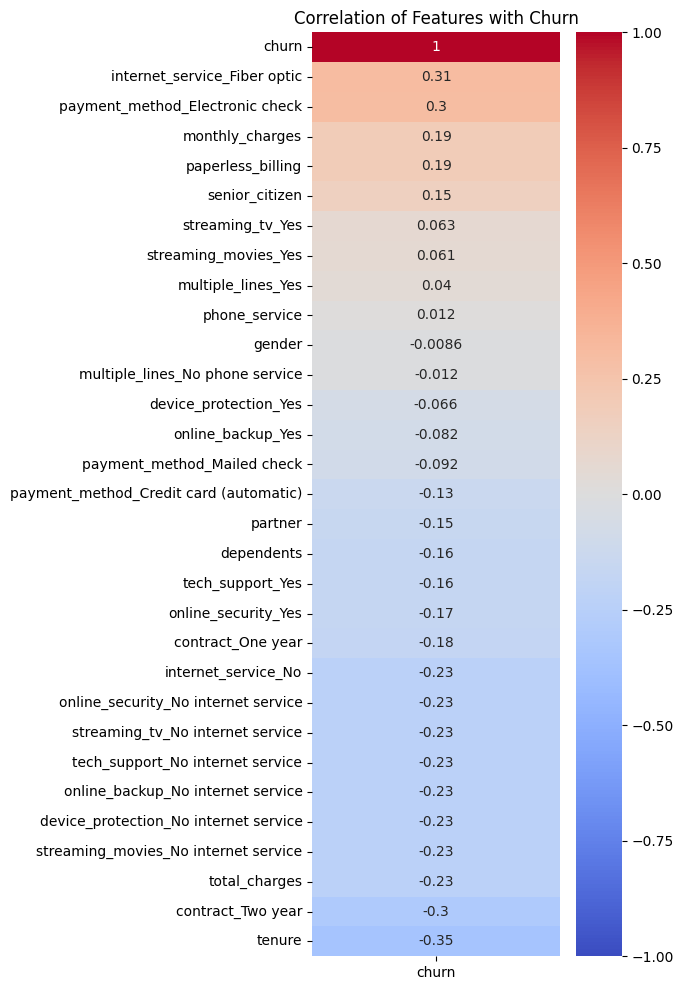

In [ ]:
# Calculating the correlation matrix for the numeric columns in the dataset to understand the relationships between different features and to identify any potential multicollinearity issues that may need to be addressed before modeling.
corr_matrix = df.corr(numeric_only=True)

# Focusing on the correlation of each feature with the 'churn' column by selecting the 'churn' column from the correlation matrix and sorting the values in descending order to identify which features have the strongest positive or negative correlation with customer churn, which can help inform feature selection and modeling decisions for customer churn prediction.
churn_corr = corr_matrix[['churn']].sort_values(by='churn', ascending=False)

# Plotting a heatmap of the correlation of features with the 'churn' column to visually represent the strength and direction of the relationships between each feature and customer churn, which can help identify key drivers of churn and inform feature selection for modeling.
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

Negative (lower value: less likely to churn):

- tenure (-0.35): Customers who stay longer are less likely to churn.
- contract_Two year (-0.30): Customers on long-term contracts churn much less.
- contract_One year (-0.18): Same trend but weaker than two-year contracts.

Positive (higher value: more likely to churn):

- internet_service_Fiber optic (+0.31): Fiber optic users churn more in this dataset.
- mayment_Method_Electronic check (+0.30): Customers paying electronically via check churn more.

##### Looking for Multi-Collinearity(VIF)

In [ ]:
# Creating a new column 'no_internet_service' that indicates whether a customer has no internet service based on the presence of 'No internet service' in any of the related internet service features, which can help capture the overall lack of internet service as a single feature for analysis and modeling.
df['no_internet_service'] = (
    df['online_security_No internet service'] |
    df['online_backup_No internet service'] |
    df['device_protection_No internet service'] |
    df['tech_support_No internet service'] |
    df['streaming_tv_No internet service'] |
    df['streaming_movies_No internet service']
)

In [ ]:
# Identifying columns related to 'no_internet_service' for potential removal
drop_cols = [col for col in df.columns if 'internet service' in col]
# Dropping the original redundant dummies
df = df.drop(columns=drop_cols)
# Dropping the original redundant dummies
df = df.drop(columns= 'internet_service_No')

In [ ]:
# Handling Phone Service Redundancy by creating a new column 'no_phone_service' that indicates whether a customer has no phone service based on the presence of 'No phone service' in the 'multiple_lines' feature, and then dropping the original redundant dummy column to simplify the dataset and reduce multicollinearity issues in modeling.
if 'multiple_lines_No phone service' in df.columns:
    df['no_phone_service'] = df['multiple_lines_No phone service'].astype(int)
    df = df.drop(columns=['multiple_lines_No phone service'])